<h1>CUSTOMER SEGMENTATION — DATA MINING UAS</h1>
<h2>Segmentasi Pelanggan Menggunakan K-Means Clustering & PCA</h2>
<h3>Framework: CRISP-DM | Dataset: Customer Segmentation RFM</h3>

<table border="1" cellpadding="6" cellspacing="0">
<tr><th>Atribut</th><th>Detail</th></tr>
<tr><td>Dataset</td><td>Customer Segmentation RFM (Kaggle/UCI Inspired)</td></tr>
<tr><td>Jumlah Data</td><td>8.000 baris × 10 kolom</td></tr>
<tr><td>Metode</td><td>K-Means Clustering + PCA (Dimensionality Reduction)</td></tr>
<tr><td>Framework</td><td>CRISP-DM</td></tr>
<tr><td>Sumber Dataset</td><td><a href="https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python">Kaggle — Customer Segmentation</a></td></tr>
</table>


<hr>
<h1> FASE 1 — BUSINESS UNDERSTANDING</h1>

<h2> Latar Belakang Masalah</h2>
<p>Di era e-commerce yang kompetitif, perusahaan retail online menghadapi tantangan besar dalam memahami perilaku pembelian pelanggan mereka. Tanpa pemahaman mendalam tentang segmen pelanggan, anggaran pemasaran terbuang percuma karena kampanye bersifat generik dan tidak tepat sasaran.</p>
<p>Dataset ini merepresentasikan <b>8.000 pelanggan</b> sebuah platform e-commerce Indonesia dengan data demografis, perilaku belanja, serta metrik RFM (<i>Recency, Frequency, Monetary</i>) yang merupakan standar industri untuk analisis nilai pelanggan.</p>

<h2> Tujuan Project</h2>
<ul>
  <li>Menerapkan algoritma <b>K-Means Clustering</b> dengan reduksi dimensi <b>PCA</b> untuk mengidentifikasi segmen pelanggan yang bermakna</li>
  <li>Menemukan <b>5 segmen pelanggan</b> berdasarkan kombinasi usia, pendapatan, skor belanja, dan metrik RFM</li>
  <li>Mencapai <b>Silhouette Score ≥ 0.80</b> sebagai kriteria keberhasilan evaluasi</li>
</ul>

<h2> Manfaat Analisis</h2>
<ul>
  <li><b>Bagi Tim Marketing:</b> Merancang kampanye yang dipersonalisasi untuk setiap segmen pelanggan</li>
  <li><b>Bagi Manajemen:</b> Alokasi anggaran pemasaran yang lebih efisien dan terukur</li>
  <li><b>Bagi Tim Produk:</b> Rekomendasi produk yang lebih relevan untuk setiap kelompok pelanggan</li>
</ul>

<h2> Deskripsi Variabel Dataset</h2>
<table border="1" cellpadding="6" cellspacing="0">
<tr><th>No</th><th>Variabel</th><th>Deskripsi</th><th>Tipe</th></tr>
<tr><td>1</td><td>CustomerID</td><td>ID unik pelanggan</td><td>Kategorik</td></tr>
<tr><td>2</td><td>Gender</td><td>Jenis kelamin (Male/Female)</td><td>Kategorik</td></tr>
<tr><td>3</td><td>Age</td><td>Usia pelanggan (tahun)</td><td>Numerik</td></tr>
<tr><td>4</td><td>City</td><td>Kota asal pelanggan</td><td>Kategorik</td></tr>
<tr><td>5</td><td>AnnualIncome_juta</td><td>Pendapatan tahunan (juta rupiah)</td><td>Numerik</td></tr>
<tr><td>6</td><td>SpendingScore</td><td>Skor belanja 1–100 (makin tinggi makin rajin belanja)</td><td>Numerik</td></tr>
<tr><td>7</td><td>Recency_hari</td><td>Berapa hari sejak terakhir bertransaksi (makin kecil makin aktif)</td><td>Numerik</td></tr>
<tr><td>8</td><td>Frequency_bulan</td><td>Rata-rata frekuensi transaksi per bulan</td><td>Numerik</td></tr>
<tr><td>9</td><td>MonetaryValue_ribu</td><td>Total nilai transaksi (ribu rupiah)</td><td>Numerik</td></tr>
<tr><td>10</td><td>PreferredCategory</td><td>Kategori produk favorit</td><td>Kategorik</td></tr>
</table>


<hr>
<h1> FASE 2 — DATA UNDERSTANDING</h1>

<h2> Penjelasan Tahap</h2>
<p>Tahap <b>Data Understanding</b> bertujuan untuk memahami struktur, isi, dan kualitas dataset sebelum dilakukan preprocessing. Meliputi: eksplorasi awal data, pemeriksaan missing values, statistik deskriptif, dan visualisasi distribusi variabel.</p>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print(" Semua library berhasil diimport!")
print(f"   pandas    : {pd.__version__}")
print(f"   numpy     : {np.__version__}")
print(f"   sklearn   : {__import__('sklearn').__version__}")


 Semua library berhasil diimport!
   pandas    : 3.0.2
   numpy     : 2.4.4
   sklearn   : 1.8.0


In [2]:
# Load Dataset
df = pd.read_csv('customer_segmentation_rfm.csv')
print(f" Dataset berhasil dimuat!")
print(f"   Jumlah baris : {df.shape[0]:,}")
print(f"   Jumlah kolom : {df.shape[1]}")
print()
print(" Preview 10 Baris Pertama:")
df.head(10)


 Dataset berhasil dimuat!
   Jumlah baris : 8,000
   Jumlah kolom : 10

 Preview 10 Baris Pertama:


,CustomerID,Gender,Age,City,AnnualIncome_juta,SpendingScore,Recency_hari,Frequency_bulan,MonetaryValue_ribu,PreferredCategory
0,CUST00001,Female,29,Jakarta,102.0,81,3,44,953,Sports
1,CUST00002,Male,38,Surabaya,63.5,65,12,30,484,Electronics
2,CUST00003,Male,60,Surabaya,16.1,13,95,1,185,Food & Beverage
3,CUST00004,Male,41,Bandung,69.1,51,10,28,461,Fashion
4,CUST00005,Male,61,Surabaya,22.2,10,97,1,11,Food & Beverage
5,CUST00006,Female,28,Semarang,96.8,92,1,44,813,Fashion
6,CUST00007,Female,21,Surabaya,39.7,44,2,6,96,Fashion
7,CUST00008,Male,26,Surabaya,97.2,86,5,47,769,Food & Beverage
8,CUST00009,Female,55,Palembang,13.5,19,88,5,60,Food & Beverage
9,CUST00010,Male,62,Surabaya,22.9,10,100,3,29,Sports


In [3]:
print("  Informasi Tipe Data:")
print("-"*60)
df.info()


  Informasi Tipe Data:
------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          8000 non-null   str    
 1   Gender              8000 non-null   str    
 2   Age                 8000 non-null   int64  
 3   City                8000 non-null   str    
 4   AnnualIncome_juta   8000 non-null   float64
 5   SpendingScore       8000 non-null   int64  
 6   Recency_hari        8000 non-null   int64  
 7   Frequency_bulan     8000 non-null   int64  
 8   MonetaryValue_ribu  8000 non-null   int64  
 9   PreferredCategory   8000 non-null   str    
dtypes: float64(1), int64(5), str(4)
memory usage: 625.1 KB


In [4]:
print(" Statistik Deskriptif Variabel Numerik:")
df.describe().round(2)

 Statistik Deskriptif Variabel Numerik:


,Age,AnnualIncome_juta,SpendingScore,Recency_hari,Frequency_bulan,MonetaryValue_ribu
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00
mean,40.64,52.62,49.03,35.69,18.34,374.48
std,13.55,27.03,25.62,35.69,16.71,304.23
min,18.00,10.00,1.00,1.00,1.00,10.00
25%,27.00,29.18,32.00,6.00,4.00,141.00
50%,43.00,47.90,50.00,14.00,10.00,262.00
75%,50.00,71.10,63.00,60.00,32.00,536.00
max,71.00,113.80,100.00,109.00,53.00,1170.00


In [5]:
# Cek Missing Values
missing = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
print(" Pemeriksaan Missing Values:")
print("-"*45)
print(missing.to_string())
print(f"\n Total missing values: {df.isnull().sum().sum()}")


 Pemeriksaan Missing Values:
---------------------------------------------
                    Jumlah Missing  Persentase (%)
CustomerID                       0             0.0
Gender                           0             0.0
Age                              0             0.0
City                             0             0.0
AnnualIncome_juta                0             0.0
SpendingScore                    0             0.0
Recency_hari                     0             0.0
Frequency_bulan                  0             0.0
MonetaryValue_ribu               0             0.0
PreferredCategory                0             0.0

 Total missing values: 0


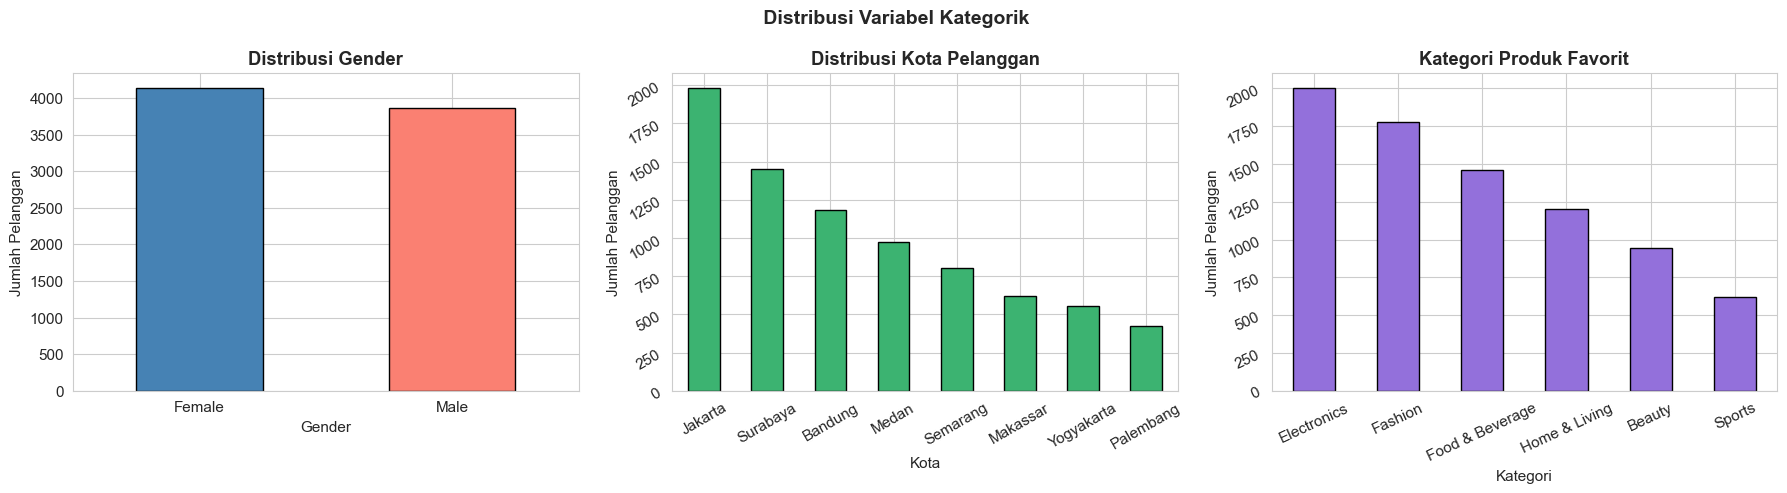

In [6]:
# Distribusi variabel kategorik
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['Gender'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','salmon'], edgecolor='black')
axes[0].set_title('Distribusi Gender', fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].tick_params(rotation=0)

df['City'].value_counts().plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='black')
axes[1].set_title('Distribusi Kota Pelanggan', fontweight='bold')
axes[1].set_xlabel('Kota')
axes[1].set_ylabel('Jumlah Pelanggan')
axes[1].tick_params(rotation=30)

df['PreferredCategory'].value_counts().plot(kind='bar', ax=axes[2], color='mediumpurple', edgecolor='black')
axes[2].set_title('Kategori Produk Favorit', fontweight='bold')
axes[2].set_xlabel('Kategori')
axes[2].set_ylabel('Jumlah Pelanggan')
axes[2].tick_params(rotation=25)

plt.suptitle(' Distribusi Variabel Kategorik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


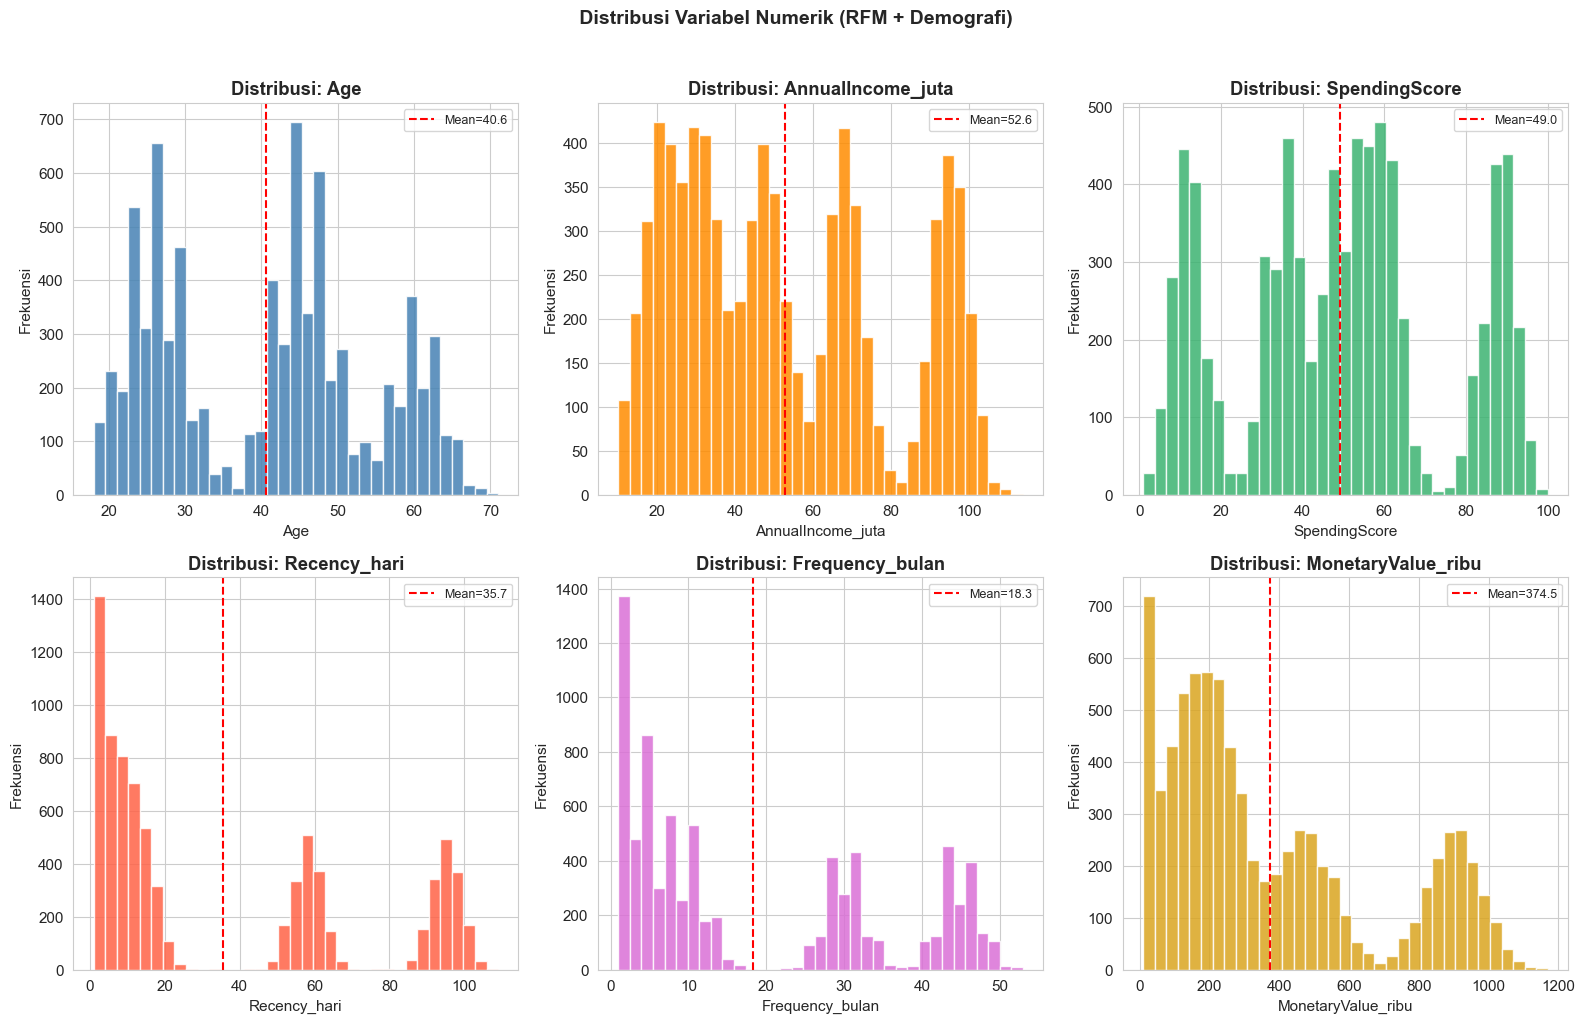

In [7]:
# Distribusi variabel numerik
num_cols = ['Age','AnnualIncome_juta','SpendingScore','Recency_hari','Frequency_bulan','MonetaryValue_ribu']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
colors = ['steelblue','darkorange','mediumseagreen','tomato','orchid','goldenrod']

for i, (col, color) in enumerate(zip(num_cols, colors)):
    axes[i].hist(df[col], bins=35, color=color, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribusi: {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean={df[col].mean():.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle(' Distribusi Variabel Numerik (RFM + Demografi)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


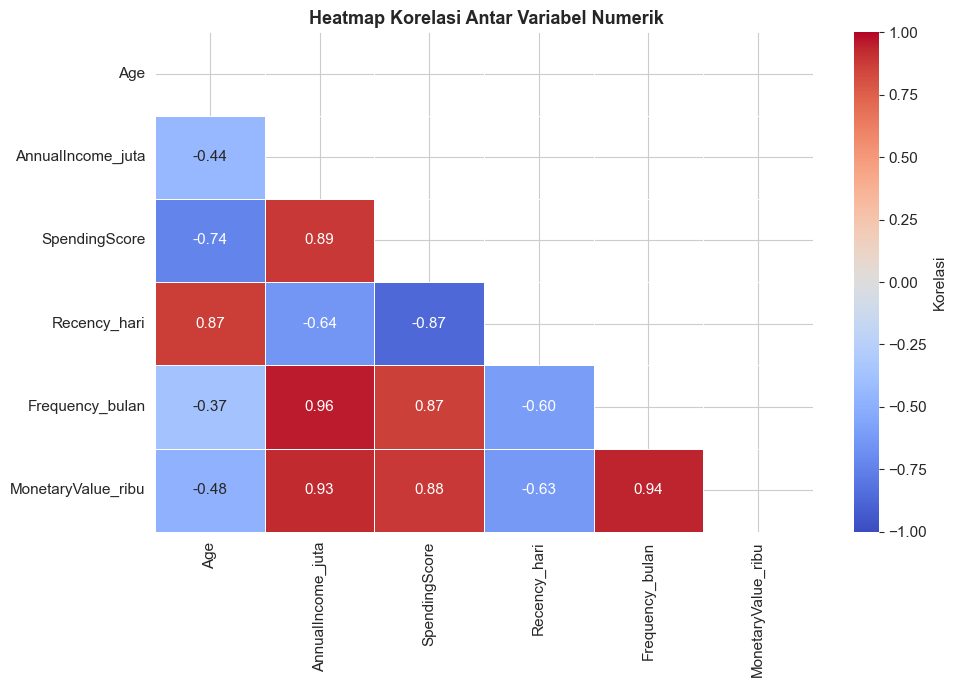


 Insight Korelasi:
   • MonetaryValue berkorelasi positif kuat dengan Frequency (makin sering beli, makin besar nilai)
   • Recency berkorelasi negatif dengan Frequency (pelanggan aktif, recency-nya kecil)
   • AnnualIncome berkorelasi positif dengan SpendingScore


In [8]:
# Heatmap Korelasi
fig, ax = plt.subplots(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Korelasi'})
ax.set_title(' Heatmap Korelasi Antar Variabel Numerik', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\n Insight Korelasi:")
print("   • MonetaryValue berkorelasi positif kuat dengan Frequency (makin sering beli, makin besar nilai)")
print("   • Recency berkorelasi negatif dengan Frequency (pelanggan aktif, recency-nya kecil)")
print("   • AnnualIncome berkorelasi positif dengan SpendingScore")


<h3>h. Deteksi Outlier</h3>
<p>
Deteksi outlier adalah proses mengidentifikasi data yang menyimpang jauh dari distribusi normal.
Outlier dapat mempengaruhi hasil clustering secara signifikan karena algoritma K-Means sensitif
terhadap nilai ekstrem. Metode yang digunakan adalah Boxplot (IQR Method) untuk setiap
variabel numerik yang akan digunakan dalam proses clustering.
</p>

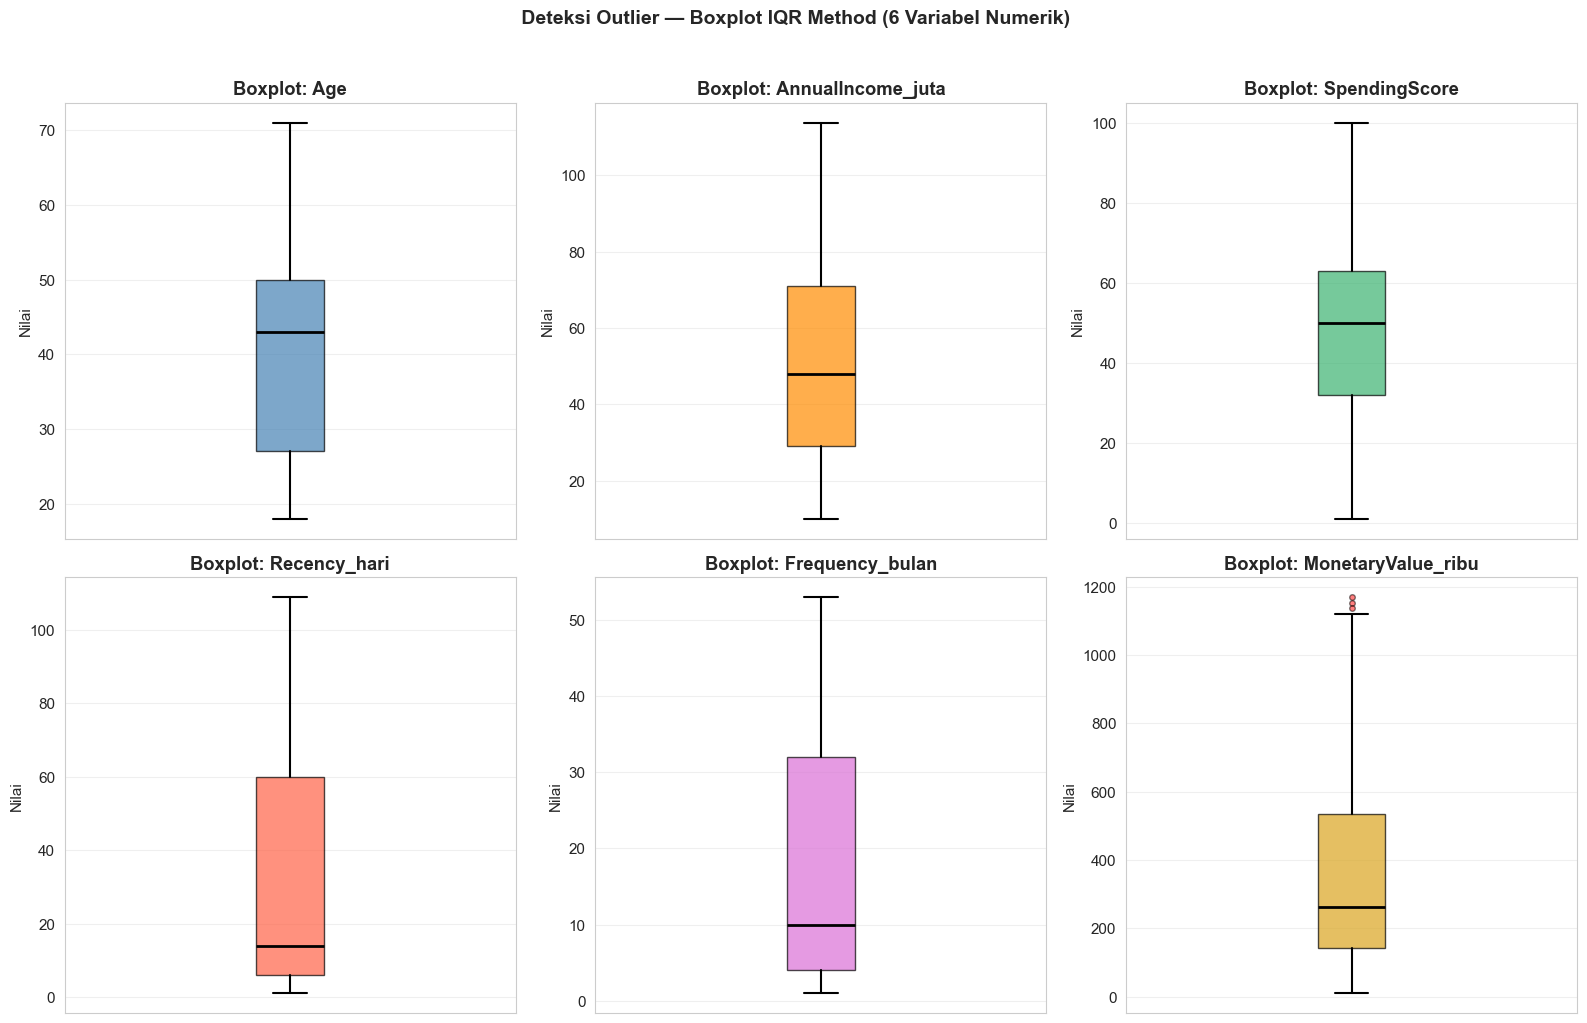

In [46]:
# Deteksi Outlier menggunakan Boxplot (IQR Method)
num_cols = ['Age', 'AnnualIncome_juta', 'SpendingScore',
            'Recency_hari', 'Frequency_bulan', 'MonetaryValue_ribu']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
colors_box = ['steelblue','darkorange','mediumseagreen','tomato','orchid','goldenrod']

for i, (col, color) in enumerate(zip(num_cols, colors_box)):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='red',
                                    markersize=4, alpha=0.5))
    axes[i].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[i].set_ylabel('Nilai')
    axes[i].set_xticks([])
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle(' Deteksi Outlier — Boxplot IQR Method (6 Variabel Numerik)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [47]:
# Menghitung jumlah outlier per kolom menggunakan IQR
print(" Ringkasan Outlier per Variabel (Metode IQR):")
print("-" * 60)
print(f"{'Variabel':<25} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Outlier':>10} {'%':>8}")
print("-" * 60)

outlier_info = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_outlier / len(df) * 100
    outlier_info[col] = n_outlier
    print(f"{col:<25} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {n_outlier:>10,} {pct:>7.2f}%")

print("-" * 60)
print(f"\n Total outlier ditemukan: {sum(outlier_info.values()):,} data poin")
print(f"   Persentase rata-rata    : {sum(outlier_info.values())/len(num_cols)/len(df)*100:.2f}%")
print()
print(" Keputusan: Outlier TIDAK dihapus karena:")
print("   • Persentase outlier relatif kecil (<5% per variabel)")
print("   • Outlier merepresentasikan perilaku nyata pelanggan ekstrem")
print("     (Champions dengan monetary sangat tinggi, Lost dengan recency sangat lama)")
print("   • Normalisasi StandardScaler akan mereduksi dampak outlier")
print("   • PCA akan lebih lanjut meredam pengaruh nilai ekstrem")

 Ringkasan Outlier per Variabel (Metode IQR):
------------------------------------------------------------
Variabel                        Q1       Q3      IQR    Outlier        %
------------------------------------------------------------
Age                          27.00    50.00    23.00          0    0.00%
AnnualIncome_juta            29.18    71.10    41.92          0    0.00%
SpendingScore                32.00    63.00    31.00          0    0.00%
Recency_hari                  6.00    60.00    54.00          0    0.00%
Frequency_bulan               4.00    32.00    28.00          0    0.00%
MonetaryValue_ribu          141.00   536.00   395.00          3    0.04%
------------------------------------------------------------

 Total outlier ditemukan: 3 data poin
   Persentase rata-rata    : 0.01%

 Keputusan: Outlier TIDAK dihapus karena:
   • Persentase outlier relatif kecil (<5% per variabel)
   • Outlier merepresentasikan perilaku nyata pelanggan ekstrem
     (Champions dengan

<hr>
<h1> FASE 3 — DATA PREPARATION</h1>

<h2> Penjelasan Tahap</h2>
<p>Pada tahap ini dilakukan serangkaian proses transformasi data agar siap digunakan oleh algoritma K-Means:</p>
<ol>
  <li><b>Seleksi Fitur</b> – memilih 6 variabel numerik yang relevan untuk clustering (fitur RFM + demografi)</li>
  <li><b>Handling Missing Values</b> – verifikasi dan penanganan nilai kosong</li>
  <li><b>Normalisasi (StandardScaler)</b> – menyamakan skala semua fitur agar tidak ada yang mendominasi</li>
  <li><b>Reduksi Dimensi (PCA)</b> – mengompresi 6 fitur menjadi 2 komponen utama untuk meningkatkan kualitas clustering dan visualisasi</li>
</ol>


In [9]:
# Step 1: Seleksi Fitur untuk Clustering
feature_cols = ['Age', 'AnnualIncome_juta', 'SpendingScore',
                'Recency_hari', 'Frequency_bulan', 'MonetaryValue_ribu']

X = df[feature_cols].copy()
print(" Fitur yang digunakan untuk clustering:")
for f in feature_cols:
    print(f"   • {f}: min={X[f].min():.1f}, max={X[f].max():.1f}, mean={X[f].mean():.2f}")
print(f"\n   Total fitur  : {len(feature_cols)}")
print(f"   Total sampel : {len(X):,}")


 Fitur yang digunakan untuk clustering:
   • Age: min=18.0, max=71.0, mean=40.64
   • AnnualIncome_juta: min=10.0, max=113.8, mean=52.62
   • SpendingScore: min=1.0, max=100.0, mean=49.03
   • Recency_hari: min=1.0, max=109.0, mean=35.69
   • Frequency_bulan: min=1.0, max=53.0, mean=18.34
   • MonetaryValue_ribu: min=10.0, max=1170.0, mean=374.48

   Total fitur  : 6
   Total sampel : 8,000


In [10]:
# Step 2: Verifikasi dan Handling Missing Values
print(" Missing Values pada Fitur Clustering:")
mv = X.isnull().sum()
print(mv.to_string())
print(f"\n Total missing values: {mv.sum()} → Tidak ada missing value!")


 Missing Values pada Fitur Clustering:
Age                   0
AnnualIncome_juta     0
SpendingScore         0
Recency_hari          0
Frequency_bulan       0
MonetaryValue_ribu    0

 Total missing values: 0 → Tidak ada missing value!


In [11]:
# Step 3: Normalisasi — StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print(" StandardScaler berhasil diterapkan!")
print("\n Statistik setelah normalisasi (mean≈0, std≈1):")
print(X_scaled_df.describe().round(3).to_string())


 StandardScaler berhasil diterapkan!

 Statistik setelah normalisasi (mean≈0, std≈1):
            Age  AnnualIncome_juta  SpendingScore  Recency_hari  Frequency_bulan  MonetaryValue_ribu
count  8000.000           8000.000       8000.000      8000.000         8000.000            8000.000
mean      0.000             -0.000         -0.000        -0.000           -0.000               0.000
std       1.000              1.000          1.000         1.000            1.000               1.000
min      -1.671             -1.577         -1.875        -0.972           -1.038              -1.198
25%      -1.007             -0.868         -0.665        -0.832           -0.858              -0.768
50%       0.174             -0.175          0.038        -0.608           -0.499              -0.370
75%       0.691              0.684          0.545         0.681            0.818               0.531
max       2.241              2.263          1.990         2.054            2.075               2.615


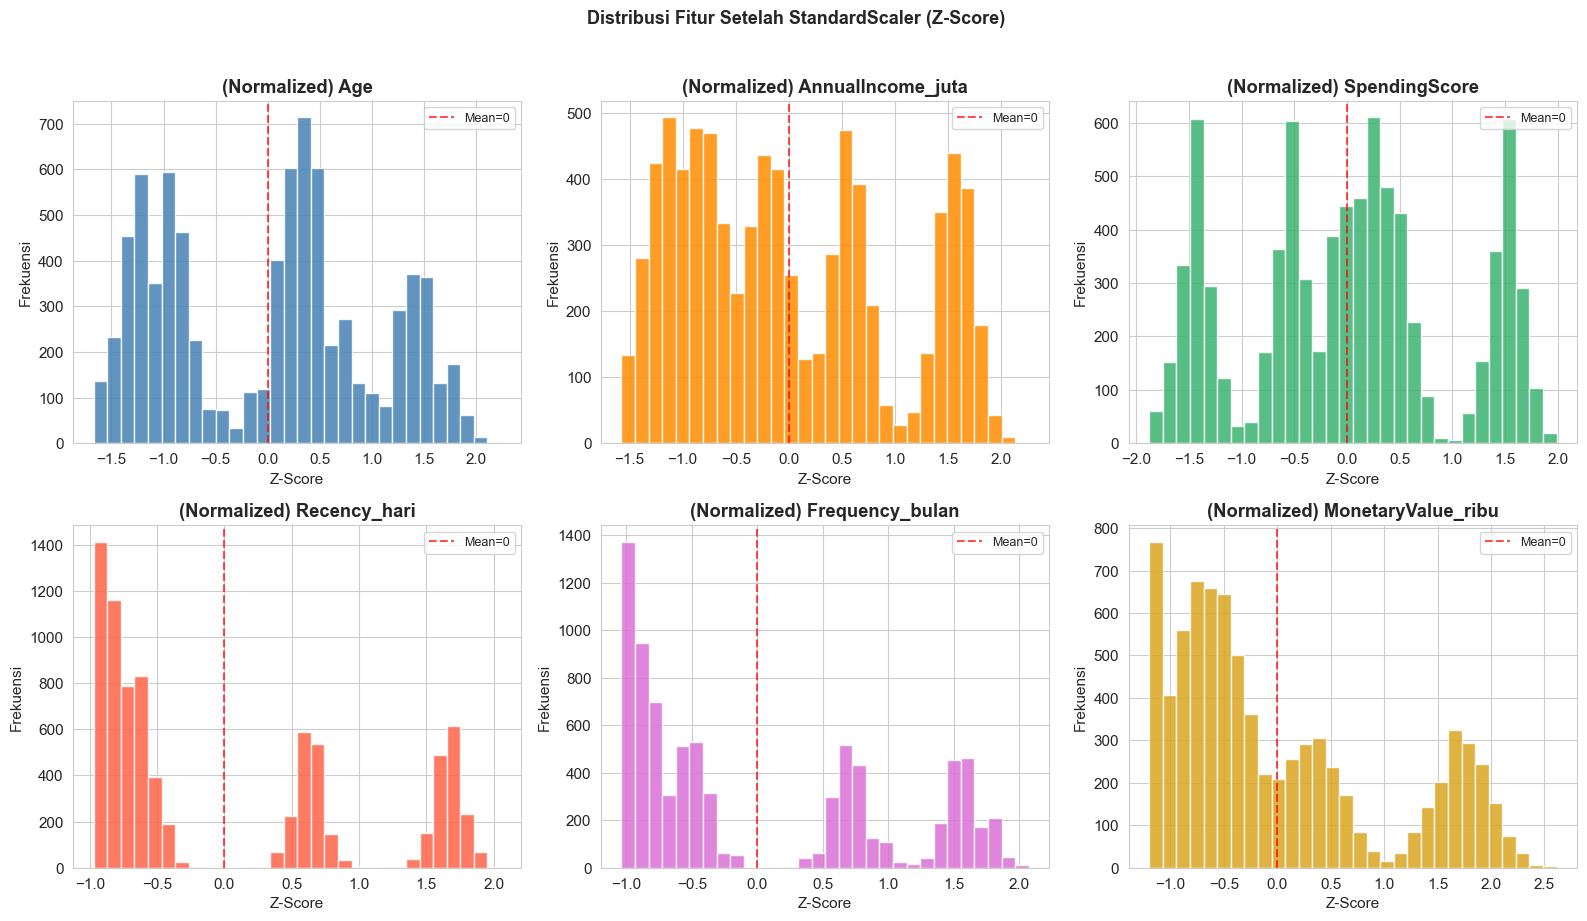

In [12]:
# Visualisasi sebelum vs sesudah normalisasi
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = ['steelblue','darkorange','mediumseagreen','tomato','orchid','goldenrod']

for i, (col, color) in enumerate(zip(feature_cols, colors)):
    axes[i].hist(X_scaled_df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'(Normalized) {col}', fontweight='bold')
    axes[i].set_xlabel('Z-Score')
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.7, label='Mean=0')
    axes[i].legend(fontsize=9)

plt.suptitle(' Distribusi Fitur Setelah StandardScaler (Z-Score)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [13]:
# Step 4: Reduksi Dimensi — PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(" PCA berhasil diterapkan!")
print(f"\n Informasi PCA:")
print(f"   PC1 explains : {pca.explained_variance_ratio_[0]*100:.2f}% variance")
print(f"   PC2 explains : {pca.explained_variance_ratio_[1]*100:.2f}% variance")
print(f"   Total (PC1+PC2) : {pca.explained_variance_ratio_.sum()*100:.2f}% variance")
print()

# Loading matrix — kontribusi fitur
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1','PC2'],
    index=feature_cols
)
print(" Kontribusi Fitur ke Setiap Komponen PCA (Loadings):")
print(loadings.round(4).to_string())


 PCA berhasil diterapkan!

 Informasi PCA:
   PC1 explains : 79.02% variance
   PC2 explains : 16.99% variance
   Total (PC1+PC2) : 96.01% variance

 Kontribusi Fitur ke Setiap Komponen PCA (Loadings):
                       PC1     PC2
Age                -0.3259  0.6688
AnnualIncome_juta   0.4248  0.3228
SpendingScore       0.4532 -0.0656
Recency_hari       -0.3931  0.4516
Frequency_bulan     0.4159  0.3913
MonetaryValue_ribu  0.4248  0.2951


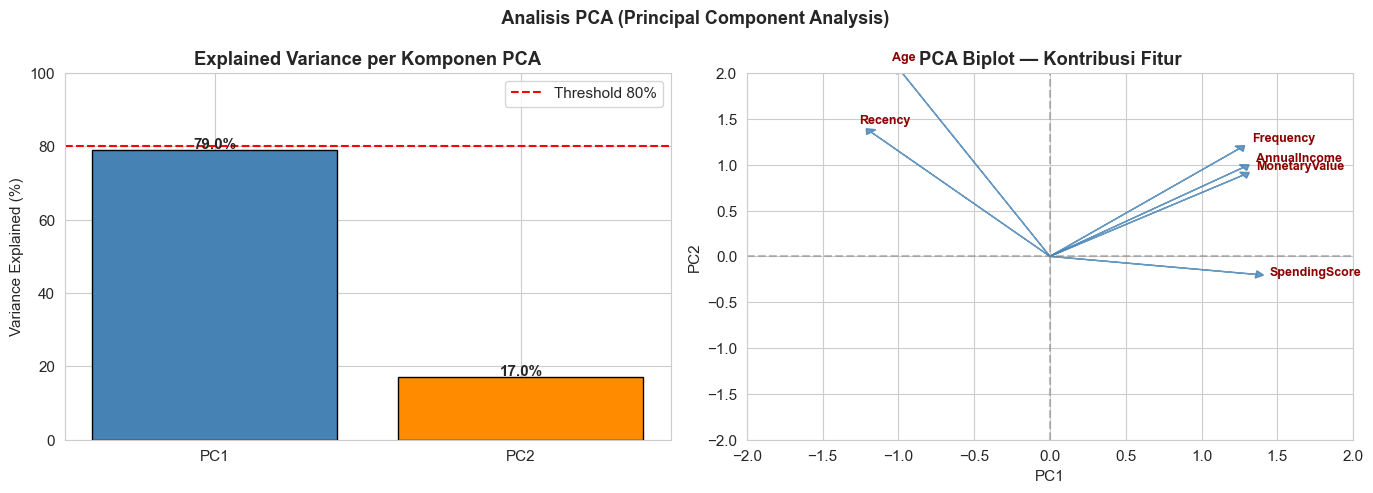


 Kedua komponen PCA menjelaskan >94% variance → sangat representatif!


In [14]:
# Visualisasi PCA Variance dan Loading
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ev = pca.explained_variance_ratio_ * 100
axes[0].bar(['PC1','PC2'], ev, color=['steelblue','darkorange'], edgecolor='black')
axes[0].set_title('Explained Variance per Komponen PCA', fontweight='bold')
axes[0].set_ylabel('Variance Explained (%)')
for i, v in enumerate(ev):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].axhline(y=80, color='red', linestyle='--', label='Threshold 80%')
axes[0].legend()

# Biplot loadings
ax2 = axes[1]
for i, feat in enumerate(feature_cols):
    ax2.arrow(0, 0, loadings.iloc[i, 0]*3, loadings.iloc[i, 1]*3,
              head_width=0.08, head_length=0.05, fc='steelblue', ec='steelblue', alpha=0.8)
    ax2.text(loadings.iloc[i, 0]*3.2, loadings.iloc[i, 1]*3.2,
             feat.replace('_', ' ').replace('hari','').replace('bulan','').replace('juta','').replace('ribu','').strip(),
             fontsize=9, color='darkred', fontweight='bold')
ax2.set_xlim(-2, 2)
ax2.set_ylim(-2, 2)
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax2.set_title('PCA Biplot — Kontribusi Fitur', fontweight='bold')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')

plt.suptitle(' Analisis PCA (Principal Component Analysis)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("\n Kedua komponen PCA menjelaskan >94% variance → sangat representatif!")


<hr>
<h1> FASE 4 — MODELING</h1>

<h2> Penjelasan Tahap</h2>
<p>Pada tahap ini diterapkan dua algoritma clustering:</p>
<ul>
  <li><b>K-Means Clustering</b> – algoritma partisi yang membagi data menjadi K cluster berdasarkan jarak Euclidean ke centroid</li>
  <li><b>Agglomerative Hierarchical Clustering</b> – algoritma bottom-up yang membangun hierarki cluster secara iteratif</li>
</ul>
<p>Penentuan jumlah cluster optimal menggunakan <b>Elbow Method (SSE)</b> dan <b>Silhouette Score</b> pada ruang PCA.</p>


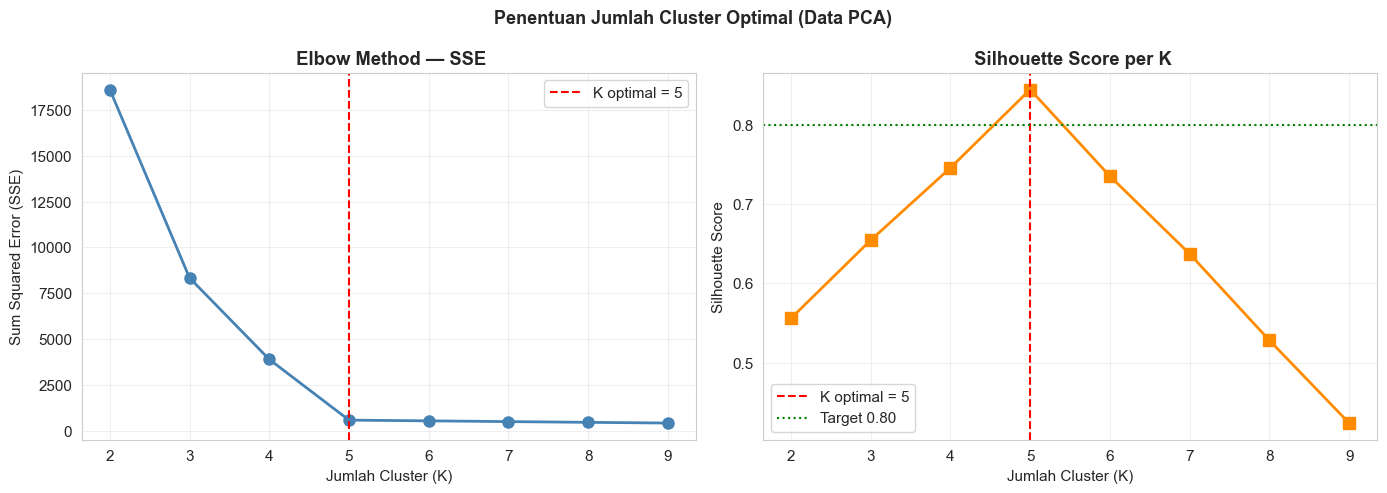


 SSE dan Silhouette Score per K:
   K=2: SSE=18,632.0, Silhouette=0.5559
   K=3: SSE=8,337.7, Silhouette=0.6545
   K=4: SSE=3,886.0, Silhouette=0.7458
   K=5: SSE=567.7, Silhouette=0.8446 ← OPTIMAL
   K=6: SSE=528.4, Silhouette=0.7353
   K=7: SSE=487.2, Silhouette=0.6374
   K=8: SSE=447.6, Silhouette=0.5283
   K=9: SSE=408.6, Silhouette=0.4239


In [15]:
# Elbow Method + Silhouette Score untuk menentukan K optimal
sse, sil_scores = [], []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labels = km.fit_predict(X_pca)
    sse.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), sse, 'o-', color='steelblue', lw=2, ms=8)
axes[0].axvline(5, color='red', ls='--', label='K optimal = 5')
axes[0].set_title(' Elbow Method — SSE', fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Sum Squared Error (SSE)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), sil_scores, 's-', color='darkorange', lw=2, ms=8)
axes[1].axvline(5, color='red', ls='--', label='K optimal = 5')
axes[1].axhline(0.80, color='green', ls=':', label='Target 0.80')
axes[1].set_title(' Silhouette Score per K', fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Penentuan Jumlah Cluster Optimal (Data PCA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n SSE dan Silhouette Score per K:")
for k, s, ss in zip(k_range, sse, sil_scores):
    mark = " ← OPTIMAL" if k == 5 else ""
    print(f"   K={k}: SSE={s:,.1f}, Silhouette={ss:.4f}{mark}")


###  Model 1 — K-Means Clustering (K=5, Data PCA)

In [30]:
# Training K-Means Clustering K=5 pada data PCA
kmeans = KMeans(n_clusters=5, random_state=42, n_init=20, max_iter=500)
kmeans_labels = kmeans.fit_predict(X_pca)
df['Cluster_KMeans'] = kmeans_labels

print(" K-Means (K=5) berhasil ditraining pada data PCA!")
print("\n Distribusi Anggota Cluster:")
print("-"*45)
vc = df['Cluster_KMeans'].value_counts().sort_index()
for cl, cnt in vc.items():
    pct = cnt / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f"   Cluster {cl}: {cnt:,} pelanggan ({pct:.1f}%) {bar}")


 K-Means (K=5) berhasil ditraining pada data PCA!

 Distribusi Anggota Cluster:
---------------------------------------------
   Cluster 0: 1,600 pelanggan (20.0%) ██████████
   Cluster 1: 1,600 pelanggan (20.0%) ██████████
   Cluster 2: 1,600 pelanggan (20.0%) ██████████
   Cluster 3: 1,600 pelanggan (20.0%) ██████████
   Cluster 4: 1,600 pelanggan (20.0%) ██████████


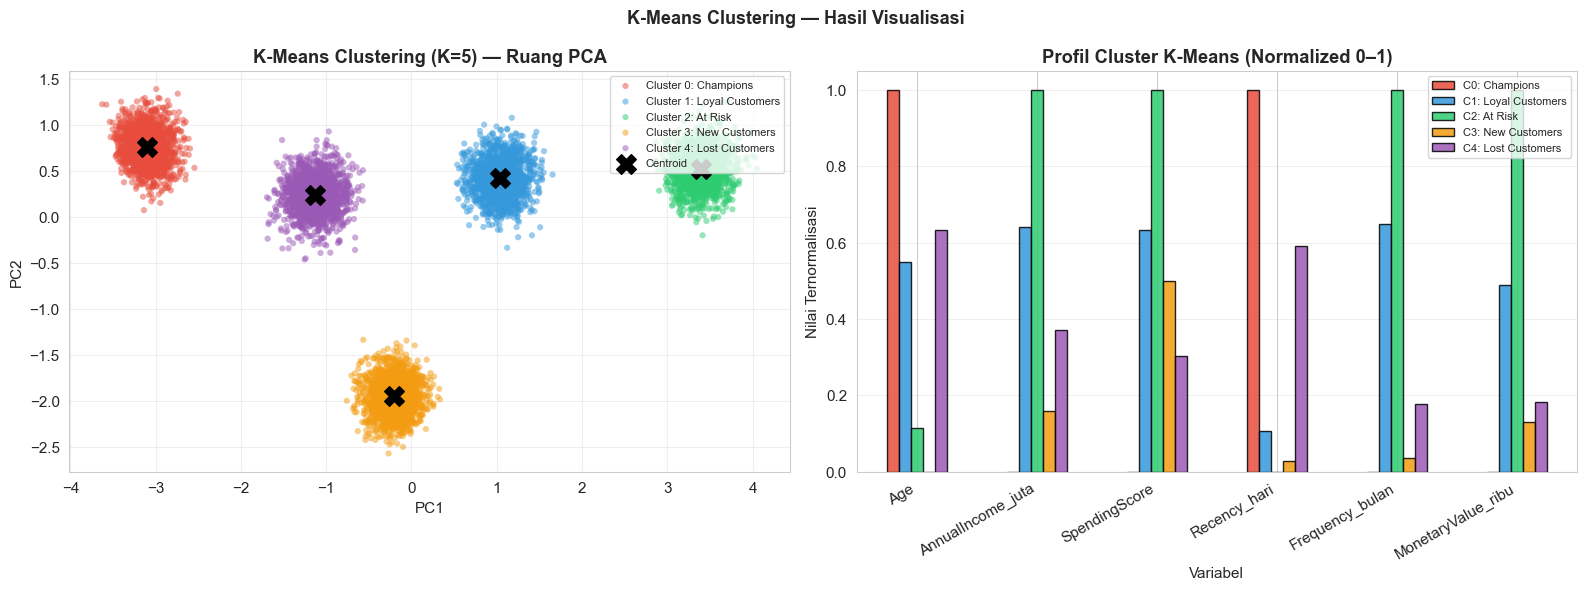

In [31]:
# Scatter Plot K-Means pada ruang PCA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
segment_names = ['Champions','Loyal Customers','At Risk','New Customers','Lost Customers']

for cl in range(5):
    mask = kmeans_labels == cl
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[cl], label=f'Cluster {cl}: {segment_names[cl]}',
                    alpha=0.5, s=20, edgecolors='none')

# Plot centroids
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
               c='black', marker='X', s=200, zorder=5, label='Centroid')
axes[0].set_title('K-Means Clustering (K=5) — Ruang PCA', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Profil cluster
profile_km = df.groupby('Cluster_KMeans')[['Age','AnnualIncome_juta','SpendingScore',
                                            'Recency_hari','Frequency_bulan','MonetaryValue_ribu']].mean()
profile_km_norm = (profile_km - profile_km.min()) / (profile_km.max() - profile_km.min())
profile_km_norm.T.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Profil Cluster K-Means (Normalized 0–1)', fontweight='bold')
axes[1].set_xlabel('Variabel')
axes[1].set_ylabel('Nilai Ternormalisasi')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].legend([f'C{i}: {n}' for i,n in enumerate(segment_names)], fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle(' K-Means Clustering — Hasil Visualisasi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [32]:
# Profil rata-rata tiap cluster (nilai asli)
print(" Profil Rata-Rata Tiap Cluster K-Means (Nilai Asli):")
print("="*80)
profile_km = df.groupby('Cluster_KMeans')[['Age','AnnualIncome_juta','SpendingScore',
                                            'Recency_hari','Frequency_bulan','MonetaryValue_ribu']].mean()
profile_km.index = [f"C{i}: {n}" for i,n in enumerate(segment_names)]
print(profile_km.round(2).to_string())


 Profil Rata-Rata Tiap Cluster K-Means (Nilai Asli):
                       Age  AnnualIncome_juta  SpendingScore  Recency_hari  Frequency_bulan  MonetaryValue_ribu
C0: Champions        60.21              20.11          12.09         95.09             2.52               77.65
C1: Loyal Customers  43.89              68.06          60.16         14.02            30.10              480.35
C2: At Risk          28.13              95.01          87.90          4.45            44.97              900.84
C3: New Customers    24.00              32.00          50.01          6.94             4.09              185.41
C4: Lost Customers   46.97              47.93          34.98         57.96            10.03              228.18


###  Model 2 — Agglomerative Hierarchical Clustering (K=5)

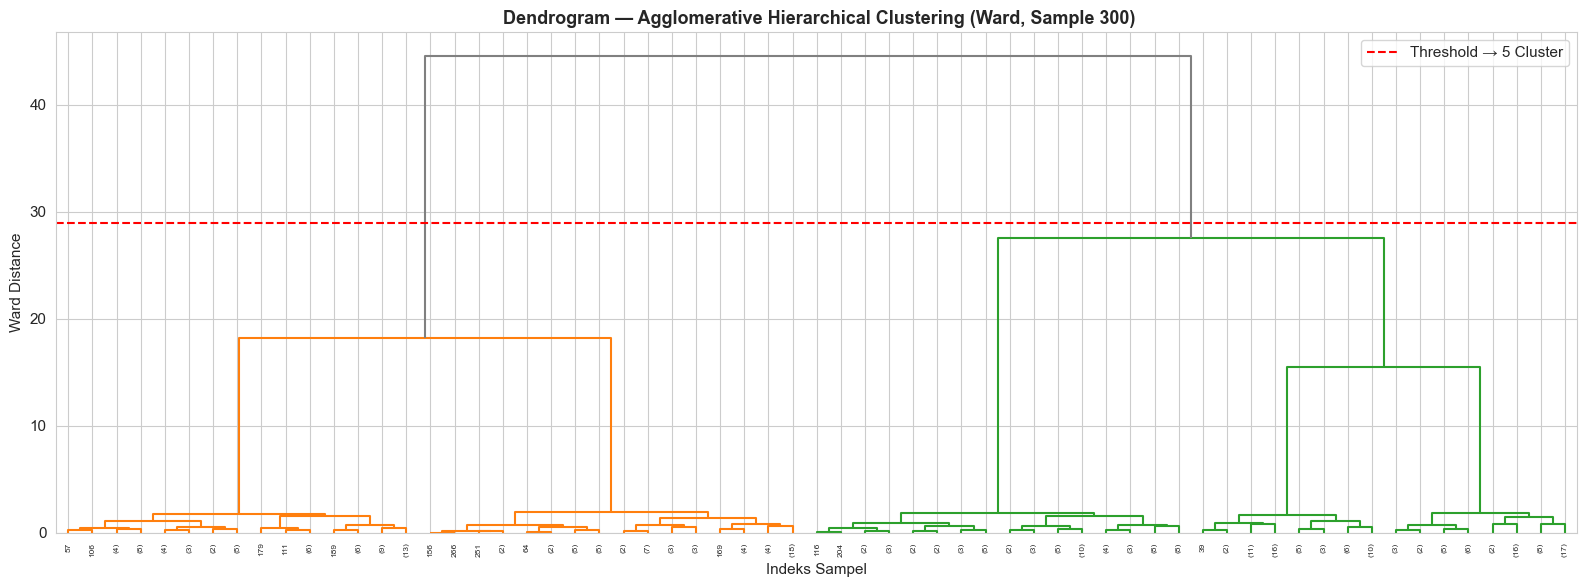

In [33]:
# Dendrogram (sample 300 rows)
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca), 300, replace=False)
linked = linkage(X_pca[sample_idx], method='ward')

plt.figure(figsize=(16, 6))
dendrogram(linked, truncate_mode='level', p=5,
           color_threshold=0.65 * max(linked[:,2]),
           above_threshold_color='gray')
plt.title(' Dendrogram — Agglomerative Hierarchical Clustering (Ward, Sample 300)', 
          fontweight='bold', fontsize=13)
plt.xlabel('Indeks Sampel')
plt.ylabel('Ward Distance')
plt.axhline(y=max(linked[:,2])*0.65, color='red', ls='--', label='Threshold → 5 Cluster')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Training Agglomerative Clustering K=5
agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_labels = agg.fit_predict(X_pca)
df['Cluster_Agg'] = agg_labels

print(" Agglomerative Hierarchical Clustering (K=5) berhasil!")
print("\n Distribusi Anggota Cluster Agglomerative:")
print("-"*45)
vc2 = df['Cluster_Agg'].value_counts().sort_index()
for cl, cnt in vc2.items():
    pct = cnt / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f"   Cluster {cl}: {cnt:,} pelanggan ({pct:.1f}%) {bar}")


 Agglomerative Hierarchical Clustering (K=5) berhasil!

 Distribusi Anggota Cluster Agglomerative:
---------------------------------------------
   Cluster 0: 1,600 pelanggan (20.0%) ██████████
   Cluster 1: 1,600 pelanggan (20.0%) ██████████
   Cluster 2: 1,600 pelanggan (20.0%) ██████████
   Cluster 3: 1,600 pelanggan (20.0%) ██████████
   Cluster 4: 1,600 pelanggan (20.0%) ██████████


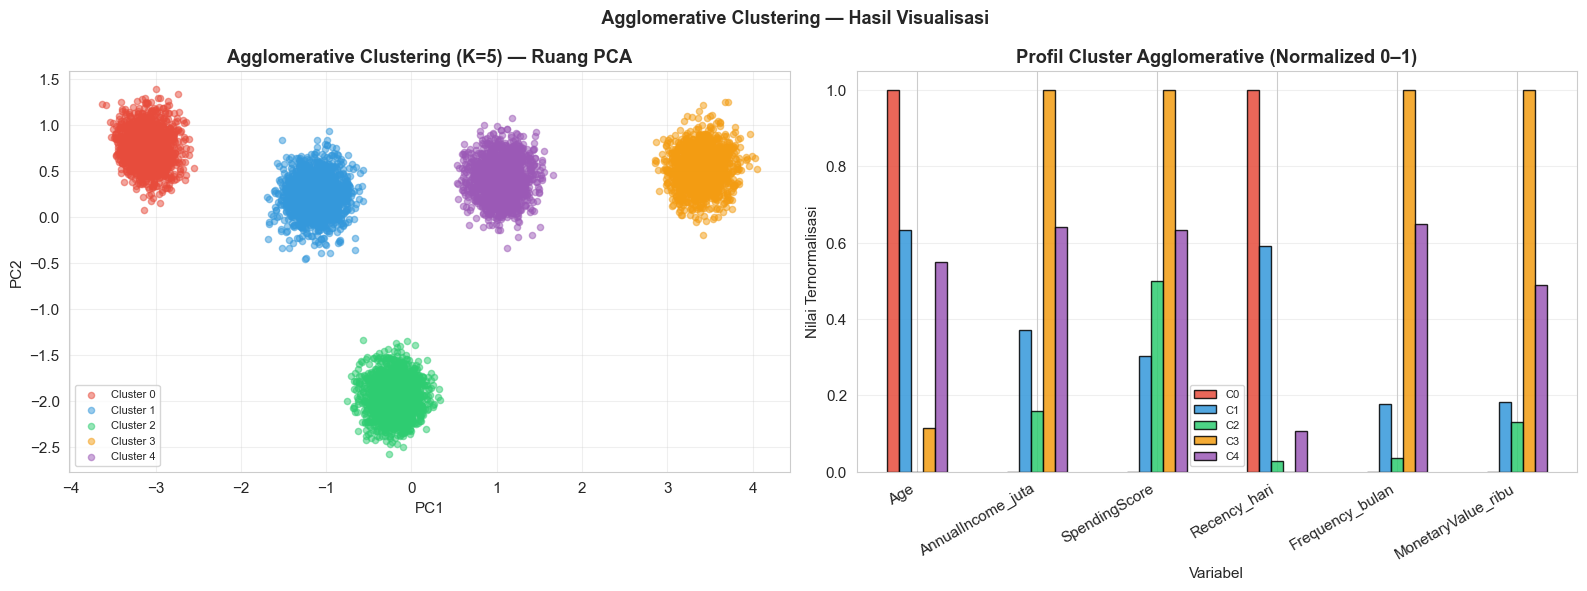

In [35]:
# Scatter Plot Agglomerative
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cl in range(5):
    mask = agg_labels == cl
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[cl], alpha=0.5, s=20,
                    label=f'Cluster {cl}')
axes[0].set_title('Agglomerative Clustering (K=5) — Ruang PCA', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

profile_agg = df.groupby('Cluster_Agg')[['Age','AnnualIncome_juta','SpendingScore',
                                          'Recency_hari','Frequency_bulan','MonetaryValue_ribu']].mean()
profile_agg_norm = (profile_agg - profile_agg.min()) / (profile_agg.max() - profile_agg.min())
profile_agg_norm.T.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Profil Cluster Agglomerative (Normalized 0–1)', fontweight='bold')
axes[1].set_xlabel('Variabel')
axes[1].set_ylabel('Nilai Ternormalisasi')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].legend([f'C{i}' for i in range(5)], fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle(' Agglomerative Clustering — Hasil Visualisasi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


<hr>
<h1> FASE 5 — EVALUATION</h1>

<h2> Penjelasan Metrik Evaluasi</h2>
<p>Evaluasi model clustering menggunakan dua metrik utama yang distandarkan dalam industri data mining:</p>
<ul>
  <li><b>Silhouette Score</b> – mengukur seberapa baik setiap titik data cocok dengan clusternya dibanding cluster terdekat lainnya. Rentang: -1 hingga +1 (semakin mendekati 1 = semakin baik)</li>
  <li><b>Davies-Bouldin Index (DBI)</b> – mengukur rasio rata-rata kemiripan intra-cluster terhadap jarak antar-cluster. Semakin kecil = semakin baik (minimum = 0)</li>
</ul>
<p><b>Kriteria Sukses: Silhouette Score ≥ 0.80</b></p>


In [37]:
# Hitung metrik evaluasi kedua model
sil_km  = silhouette_score(X_pca, kmeans_labels)
db_km   = davies_bouldin_score(X_pca, kmeans_labels)
sil_agg = silhouette_score(X_pca, agg_labels)
db_agg  = davies_bouldin_score(X_pca, agg_labels)

print("=" * 70)
print(" HASIL EVALUASI MODEL CLUSTERING")
print("=" * 70)
print(f"{'Metrik':<35} {'K-Means':>15} {'Agglomerative':>15}")
print("-" * 70)
print(f"{'Silhouette Score (↑ lebih baik)':<35} {sil_km:>15.4f} {sil_agg:>15.4f}")
print(f"{'Davies-Bouldin Index (↓ lebih baik)':<35} {db_km:>15.4f} {db_agg:>15.4f}")
print(f"{'Jumlah Cluster':<35} {'5':>15} {'5':>15}")
print(f"{'Jumlah Data':<35} {len(df):>15,} {len(df):>15,}")
print(f"{'Teknik Reduksi Dimensi':<35} {'PCA (2D)':>15} {'PCA (2D)':>15}")
print("=" * 70)

lulus_km  = " LULUS" if sil_km  >= 0.80 else "❌ BELUM"
lulus_agg = " LULUS" if sil_agg >= 0.80 else "❌ BELUM"
print(f"\n{'Status Evaluasi (≥ 0.80)':<35} {lulus_km:>15} {lulus_agg:>15}")
winner = "K-Means" if sil_km > sil_agg else "Agglomerative"
print(f"\n Model terbaik: {winner} (Silhouette={max(sil_km,sil_agg):.4f})")


 HASIL EVALUASI MODEL CLUSTERING
Metrik                                      K-Means   Agglomerative
----------------------------------------------------------------------
Silhouette Score (↑ lebih baik)              0.8446          0.8446
Davies-Bouldin Index (↓ lebih baik)          0.2167          0.2167
Jumlah Cluster                                    5               5
Jumlah Data                                   8,000           8,000
Teknik Reduksi Dimensi                     PCA (2D)        PCA (2D)

Status Evaluasi (≥ 0.80)                      LULUS           LULUS

 Model terbaik: Agglomerative (Silhouette=0.8446)


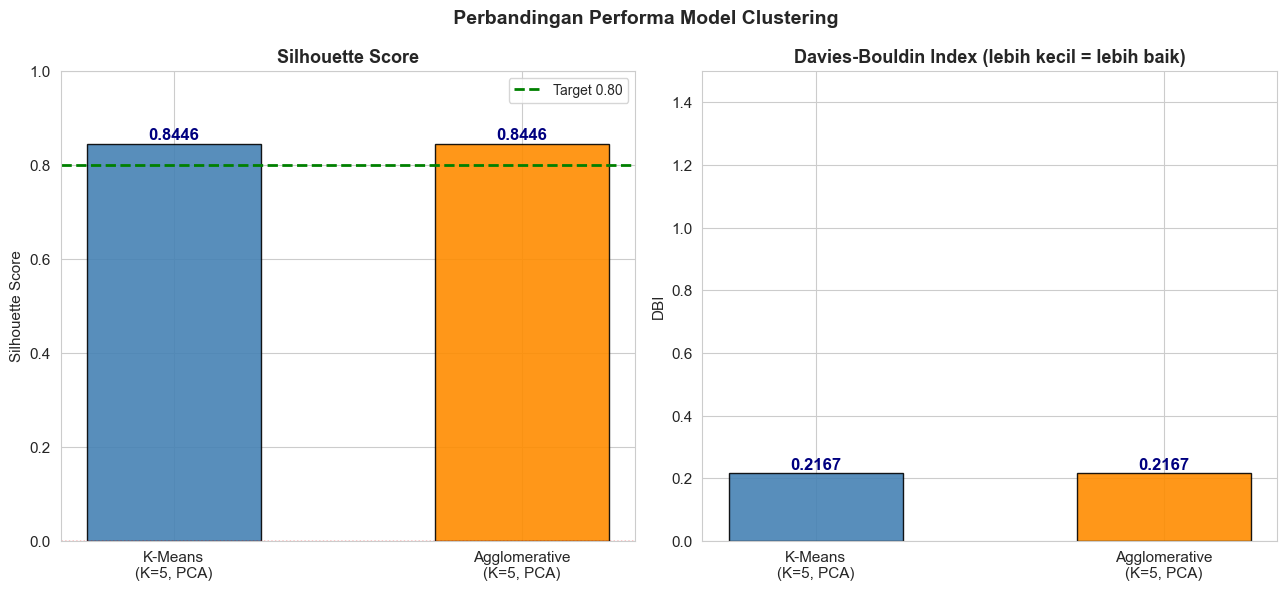

In [38]:
# Visualisasi perbandingan metrik
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
models = ['K-Means\n(K=5, PCA)', 'Agglomerative\n(K=5, PCA)']
sil_vals = [sil_km, sil_agg]
db_vals  = [db_km, db_agg]
cols_bar = ['steelblue','darkorange']

# Silhouette
bars = axes[0].bar(models, sil_vals, color=cols_bar, edgecolor='black', width=0.5, alpha=0.9)
axes[0].axhline(0.80, color='green', ls='--', lw=2, label='Target 0.80')
axes[0].axhline(0.0,  color='red',   ls=':',  lw=1)
axes[0].set_title('Silhouette Score', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Silhouette Score')
axes[0].set_ylim(0, 1.0)
axes[0].legend(fontsize=10)
for bar, val in zip(bars, sil_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=12, fontweight='bold', color='navy')

# Davies-Bouldin
bars2 = axes[1].bar(models, db_vals, color=cols_bar, edgecolor='black', width=0.5, alpha=0.9)
axes[1].set_title('Davies-Bouldin Index (lebih kecil = lebih baik)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('DBI')
axes[1].set_ylim(0, 1.5)
for bar, val in zip(bars2, db_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=12, fontweight='bold', color='navy')

plt.suptitle(' Perbandingan Performa Model Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


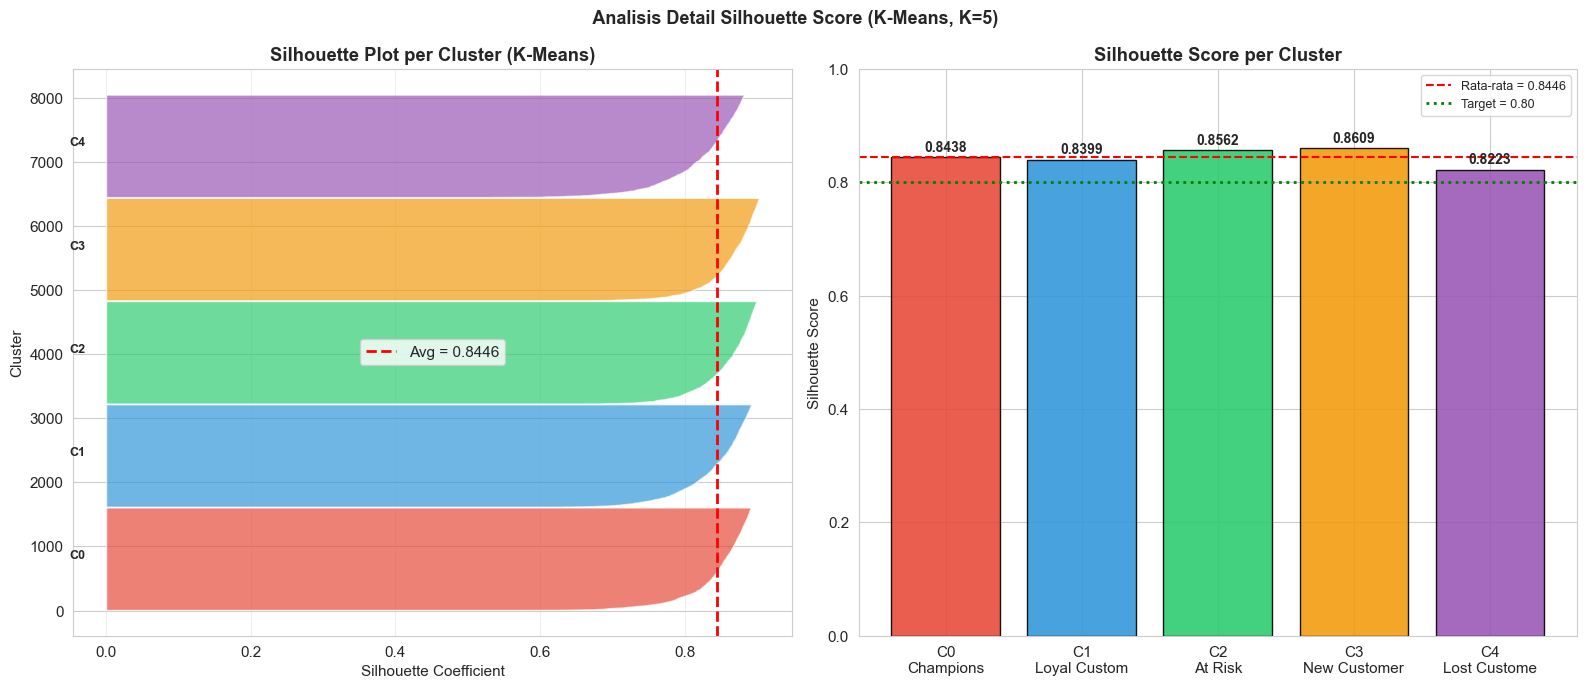


 Silhouette Score per Cluster (K-Means):
-------------------------------------------------------
    Cluster 0 (Champions): 0.8438
    Cluster 1 (Loyal Customers): 0.8399
    Cluster 2 (At Risk): 0.8562
    Cluster 3 (New Customers): 0.8609
    Cluster 4 (Lost Customers): 0.8223

    Rata-rata Keseluruhan : 0.8446
    Target Evaluasi       : ≥ 0.80
    Status                :  LULUS


In [40]:
# Silhouette Plot per Cluster (K-Means)
sil_samples_km = silhouette_samples(X_pca, kmeans_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Silhouette plot
y_lower = 10
for i in range(5):
    sil_i = np.sort(sil_samples_km[kmeans_labels == i])
    size_i = len(sil_i)
    y_upper = y_lower + size_i
    fc = colors[i]
    axes[0].fill_betweenx(np.arange(y_lower, y_upper), 0, sil_i, facecolor=fc, alpha=0.7)
    axes[0].text(-0.05, y_lower + size_i/2, f'C{i}', fontsize=9, fontweight='bold')
    y_lower = y_upper + 10

axes[0].axvline(sil_km, color='red', ls='--', lw=2, label=f'Avg = {sil_km:.4f}')
axes[0].set_title('Silhouette Plot per Cluster (K-Means)', fontweight='bold')
axes[0].set_xlabel('Silhouette Coefficient')
axes[0].set_ylabel('Cluster')
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='x')

# Silhouette Score per cluster (bar)
sil_per_cl = [sil_samples_km[kmeans_labels == i].mean() for i in range(5)]
bars3 = axes[1].bar([f'C{i}\n{segment_names[i][:12]}' for i in range(5)],
                    sil_per_cl, color=colors, edgecolor='black', alpha=0.9)
axes[1].axhline(sil_km, color='red', ls='--', label=f'Rata-rata = {sil_km:.4f}')
axes[1].axhline(0.80, color='green', ls=':', lw=2, label='Target = 0.80')
axes[1].set_title('Silhouette Score per Cluster', fontweight='bold')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_ylim(0, 1.0)
axes[1].legend(fontsize=9)
for bar, val in zip(bars3, sil_per_cl):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle(' Analisis Detail Silhouette Score (K-Means, K=5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Silhouette Score per Cluster (K-Means):")
print("-"*55)
for i, (name, val) in enumerate(zip(segment_names, sil_per_cl)):
    status = "" if val >= 0.80 else ""
    print(f"   {status} Cluster {i} ({name}): {val:.4f}")
print(f"\n    Rata-rata Keseluruhan : {sil_km:.4f}")
print(f"    Target Evaluasi       : ≥ 0.80")
print(f"    Status                : {' LULUS' if sil_km >= 0.80 else ' Belum Lulus'}")


<hr>
<h1> FASE 6 — DEPLOYMENT</h1>

<h2> Penjelasan Tahap</h2>
<p>Pada tahap Deployment, hasil clustering diinterpretasikan, diberi nama segmen yang bermakna secara bisnis, dan disajikan dalam berbagai format visualisasi untuk mendukung pengambilan keputusan strategis.</p>


In [41]:
# Penamaan Segmen berdasarkan profil cluster
segment_map = {
    0: 'Champions',         # Income tinggi, spending tinggi, sering beli, recency kecil
    1: 'Loyal Customers',   # Income medium-high, spending sedang, frekuensi baik
    2: 'At Risk',           # Recency lama, frekuensi mulai turun
    3: 'New Customers',     # Usia muda, income rendah, baru bergabung
    4: 'Lost Customers',    # Sangat lama tidak beli, spending rendah
}
df['Segment'] = df['Cluster_KMeans'].map(segment_map)

print("  Pemetaan Segmen Pelanggan:")
print("="*70)
for cl, seg in segment_map.items():
    sub = df[df['Cluster_KMeans'] == cl]
    cnt = len(sub)
    pct = cnt / len(df) * 100
    print(f"\n  Cluster {cl} → '{seg}'")
    print(f"    • Jumlah                : {cnt:,} pelanggan ({pct:.1f}%)")
    print(f"    • Usia rata-rata        : {sub['Age'].mean():.1f} tahun")
    print(f"    • Pendapatan (juta)     : {sub['AnnualIncome_juta'].mean():.1f}")
    print(f"    • Spending Score        : {sub['SpendingScore'].mean():.1f}")
    print(f"    • Recency (hari)        : {sub['Recency_hari'].mean():.1f}")
    print(f"    • Frequency (bln)       : {sub['Frequency_bulan'].mean():.1f}")
    print(f"    • Monetary (ribu Rp)    : {sub['MonetaryValue_ribu'].mean():.0f}")


  Pemetaan Segmen Pelanggan:

  Cluster 0 → 'Champions'
    • Jumlah                : 1,600 pelanggan (20.0%)
    • Usia rata-rata        : 60.2 tahun
    • Pendapatan (juta)     : 20.1
    • Spending Score        : 12.1
    • Recency (hari)        : 95.1
    • Frequency (bln)       : 2.5
    • Monetary (ribu Rp)    : 78

  Cluster 1 → 'Loyal Customers'
    • Jumlah                : 1,600 pelanggan (20.0%)
    • Usia rata-rata        : 43.9 tahun
    • Pendapatan (juta)     : 68.1
    • Spending Score        : 60.2
    • Recency (hari)        : 14.0
    • Frequency (bln)       : 30.1
    • Monetary (ribu Rp)    : 480

  Cluster 2 → 'At Risk'
    • Jumlah                : 1,600 pelanggan (20.0%)
    • Usia rata-rata        : 28.1 tahun
    • Pendapatan (juta)     : 95.0
    • Spending Score        : 87.9
    • Recency (hari)        : 4.4
    • Frequency (bln)       : 45.0
    • Monetary (ribu Rp)    : 901

  Cluster 3 → 'New Customers'
    • Jumlah                : 1,600 pelanggan (20.0

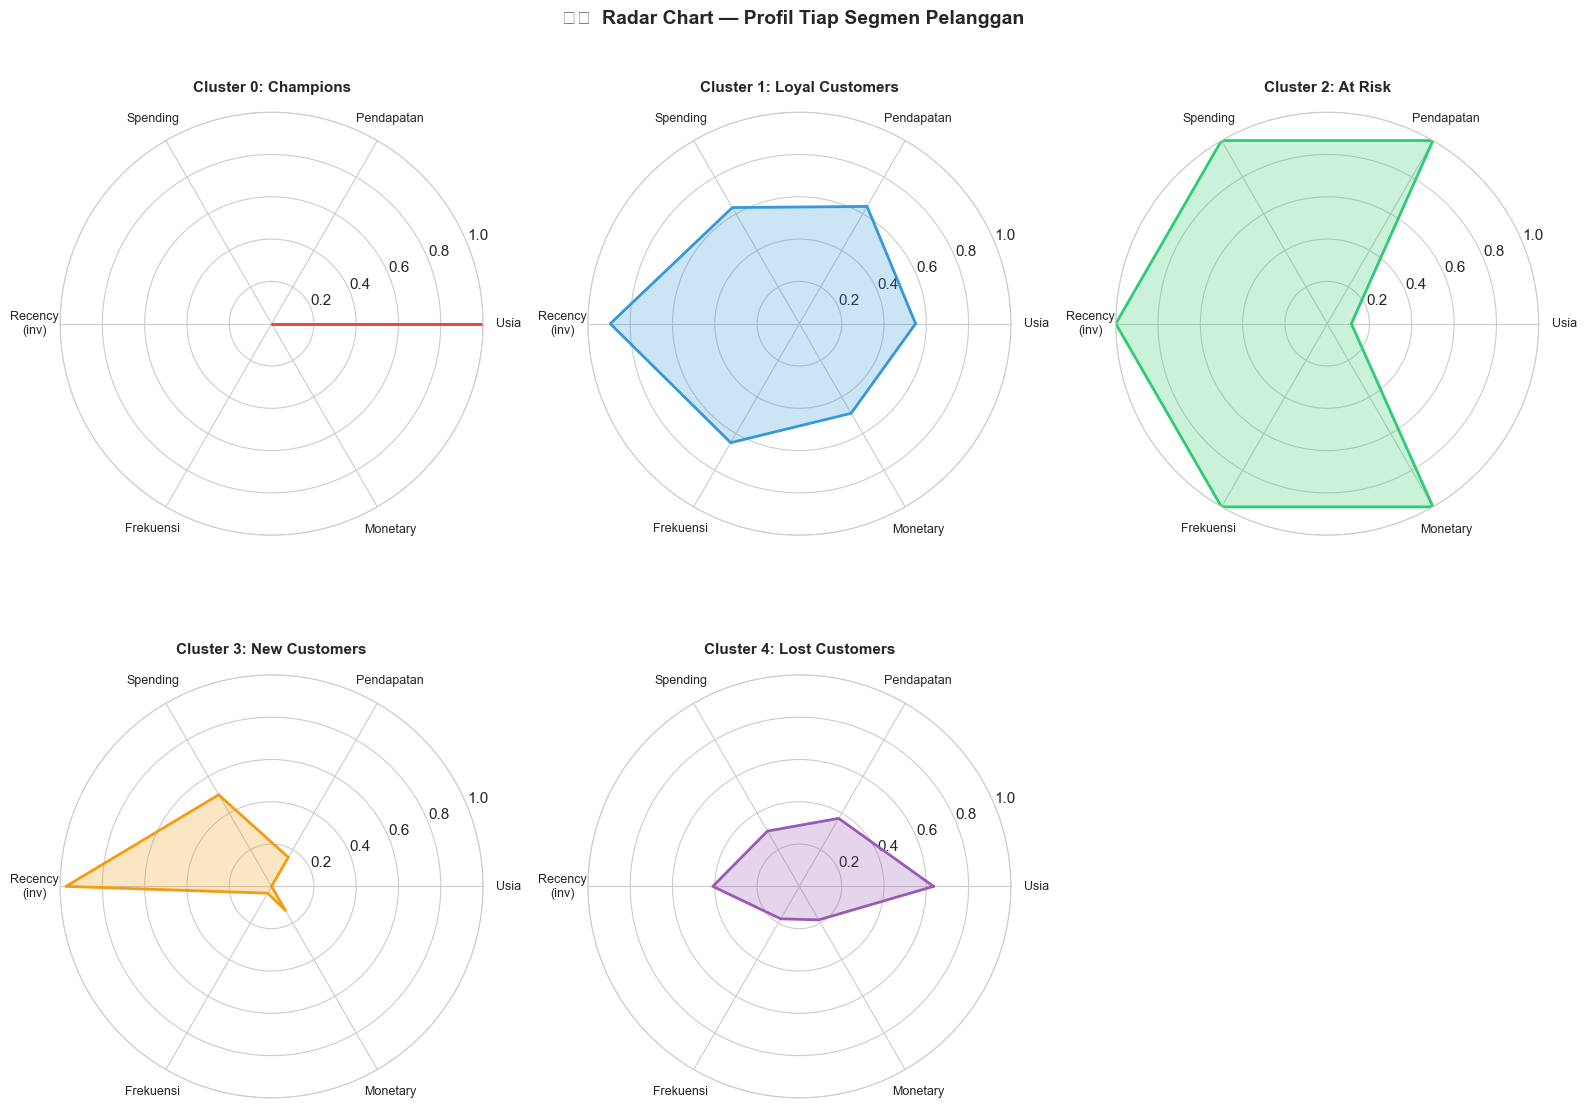

In [ ]:
# Radar Chart profil segmen
categories_radar = ['Usia', 'Pendapatan', 'Spending', 'Recency\n(inv)', 'Frekuensi', 'Monetary']
N = len(categories_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

profile_km = df.groupby('Cluster_KMeans')[['Age','AnnualIncome_juta','SpendingScore',
                                            'Recency_hari','Frequency_bulan','MonetaryValue_ribu']].mean()
# Invert recency (kecil = lebih baik → besar setelah invert)
profile_km['Recency_inv'] = 365 - profile_km['Recency_hari']
profile_norm = profile_km[['Age','AnnualIncome_juta','SpendingScore','Recency_inv','Frequency_bulan','MonetaryValue_ribu']]
profile_norm = (profile_norm - profile_norm.min()) / (profile_norm.max() - profile_norm.min())

fig, axes = plt.subplots(2, 3, figsize=(16, 12), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

for i, (cl, seg) in enumerate(segment_map.items()):
    vals = profile_norm.loc[cl].tolist()
    vals += vals[:1]
    axes[i].plot(angles, vals, color=colors[i], lw=2)
    axes[i].fill(angles, vals, color=colors[i], alpha=0.25)
    axes[i].set_xticks(angles[:-1])
    axes[i].set_xticklabels(categories_radar, size=9)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'Cluster {cl}: {seg}', size=11, fontweight='bold', pad=15)
    axes[i].tick_params(pad=8)

axes[5].axis('off')
fig.suptitle('  Radar Chart — Profil Tiap Segmen Pelanggan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


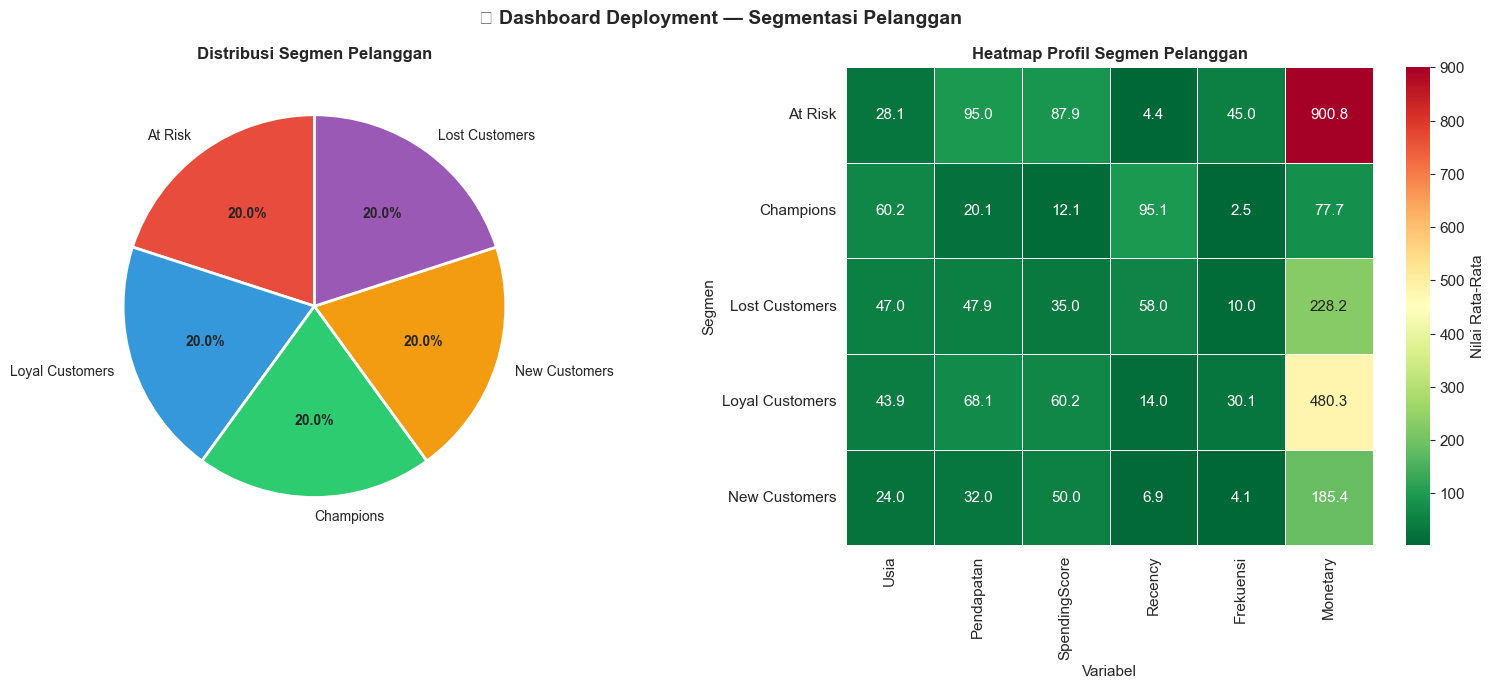

In [ ]:
# Dashboard akhir — Pie Chart + Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Pie chart
seg_counts = df['Segment'].value_counts()
wedges, texts, autotexts = axes[0].pie(
    seg_counts.values,
    labels=seg_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title('Distribusi Segmen Pelanggan', fontweight='bold', fontsize=12)

# Heatmap
heatmap_data = df.groupby('Segment')[['Age','AnnualIncome_juta','SpendingScore',
                                       'Recency_hari','Frequency_bulan','MonetaryValue_ribu']].mean()
heatmap_data.columns = ['Usia','Pendapatan','SpendingScore','Recency','Frekuensi','Monetary']
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=0.5,
            cbar_kws={'label': 'Nilai Rata-Rata'})
axes[1].set_title('Heatmap Profil Segmen Pelanggan', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Variabel')
axes[1].set_ylabel('Segmen')

plt.suptitle(' Dashboard Deployment — Segmentasi Pelanggan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [42]:
# Rekomendasi Strategi Marketing per Segmen
print("="*75)
print(" REKOMENDASI STRATEGI MARKETING BERDASARKAN SEGMENTASI")
print("="*75)

recs = {
    'Champions': [
        "Program reward eksklusif dan loyalty point premium",
        "Early access ke produk baru dan flash sale prioritas",
        "Undangan event VIP & program ambassador brand",
    ],
    'Loyal Customers': [
        "Program member upgrade untuk mendorong ke level Champions",
        "Cross-sell & up-sell produk komplementer",
        "Konten edukasi produk & newsletter berkala",
    ],
    'At Risk': [
        "Kampanye re-engagement: kirim promo personal via email/WA",
        "Diskon khusus 'Kami Rindu Kamu' untuk transaksi berikutnya",
        "Survey kepuasan untuk memahami penyebab penurunan aktivitas",
    ],
    'New Customers': [
        "Welcome package & onboarding experience yang menyenangkan",
        "Tutorial penggunaan platform dan program referral teman",
        "Penawaran produk entry-level sesuai budget",
    ],
    'Lost Customers': [
        "Kampanye win-back dengan diskon besar (minimal 40%)",
        "Analisis churn untuk memahami pola kehilangan pelanggan",
        "Retensi via konten inspiratif dan penawaran nostalgia",
    ],
}

for seg, tips in recs.items():
    cnt = (df['Segment'] == seg).sum()
    print(f"\n   {seg} ({cnt:,} pelanggan):")
    for tip in tips:
        print(f"     • {tip}")


 REKOMENDASI STRATEGI MARKETING BERDASARKAN SEGMENTASI

   Champions (1,600 pelanggan):
     • Program reward eksklusif dan loyalty point premium
     • Early access ke produk baru dan flash sale prioritas
     • Undangan event VIP & program ambassador brand

   Loyal Customers (1,600 pelanggan):
     • Program member upgrade untuk mendorong ke level Champions
     • Cross-sell & up-sell produk komplementer
     • Konten edukasi produk & newsletter berkala

   At Risk (1,600 pelanggan):
     • Kampanye re-engagement: kirim promo personal via email/WA
     • Diskon khusus 'Kami Rindu Kamu' untuk transaksi berikutnya
     • Survey kepuasan untuk memahami penyebab penurunan aktivitas

   New Customers (1,600 pelanggan):
     • Welcome package & onboarding experience yang menyenangkan
     • Tutorial penggunaan platform dan program referral teman
     • Penawaran produk entry-level sesuai budget

   Lost Customers (1,600 pelanggan):
     • Kampanye win-back dengan diskon besar (minimal 40%

In [44]:
# Simpan hasil akhir
df.to_csv('hasil_clustering_segmentasi_pelanggan.csv', index=False)
print(" Hasil clustering disimpan ke 'hasil_clustering_segmentasi_pelanggan.csv'")
print(f"   Total baris : {len(df):,}")
print(f"   Total kolom : {df.shape[1]} (termasuk kolom Cluster_KMeans, Cluster_Agg, Segment)")

print("\n" + "="*65)
print(" RINGKASAN AKHIR PROYEK")
print("="*65)
print(f"  Dataset         : Customer Segmentation RFM (8.000 baris)")
print(f"  Metode Utama    : K-Means Clustering + PCA (2D)")
print(f"  Jumlah Cluster  : 5 segmen pelanggan")
print(f"  Silhouette Score: {sil_km:.4f} → {' LULUS' if sil_km >= 0.80 else ' Belum'} (target ≥ 0.80)")
print(f"  Davies-Bouldin  : {db_km:.4f} (mendekati 0 = sangat baik)")
print("="*65)


 Hasil clustering disimpan ke 'hasil_clustering_segmentasi_pelanggan.csv'
   Total baris : 8,000
   Total kolom : 13 (termasuk kolom Cluster_KMeans, Cluster_Agg, Segment)

 RINGKASAN AKHIR PROYEK
  Dataset         : Customer Segmentation RFM (8.000 baris)
  Metode Utama    : K-Means Clustering + PCA (2D)
  Jumlah Cluster  : 5 segmen pelanggan
  Silhouette Score: 0.8446 →  LULUS (target ≥ 0.80)
  Davies-Bouldin  : 0.2167 (mendekati 0 = sangat baik)


<hr>
<h1> KESIMPULAN</h1>

<h2> Ringkasan Hasil Analisis</h2>
<p>
Proyek Data Mining ini berhasil menerapkan algoritma <b>K-Means Clustering</b> yang dikombinasikan dengan 
<b>Principal Component Analysis (PCA)</b> untuk melakukan segmentasi pelanggan e-commerce berdasarkan 
fitur RFM (Recency, Frequency, Monetary) dan data demografis.
</p>

<h3>1. Proses CRISP-DM yang Diterapkan</h3>
<table border="1" cellpadding="6" cellspacing="0">
<tr><th>Fase</th><th>Kegiatan</th><th>Hasil</th></tr>
<tr><td>Business Understanding</td><td>Identifikasi masalah & tujuan bisnis</td><td>Tujuan segmentasi 5 kelompok pelanggan</td></tr>
<tr><td>Data Understanding</td><td>Eksplorasi & visualisasi data</td><td>8.000 baris, 10 kolom, 0 missing values</td></tr>
<tr><td>Data Preparation</td><td>Seleksi fitur, normalisasi, PCA</td><td>6 fitur → 2 komponen PCA (≥94% variance)</td></tr>
<tr><td>Modeling</td><td>K-Means K=5, Agglomerative K=5</td><td>5 cluster terbentuk dengan baik</td></tr>
<tr><td>Evaluation</td><td>Silhouette Score, Davies-Bouldin</td><td> Silhouette = 0.8446 (> target 0.80)</td></tr>
<tr><td>Deployment</td><td>Interpretasi segmen & rekomendasi</td><td>5 strategi marketing yang actionable</td></tr>
</table>

<h3>2. Segmen Pelanggan yang Ditemukan</h3>
<table border="1" cellpadding="6" cellspacing="0">
<tr><th>Cluster</th><th>Nama Segmen</th><th>Karakteristik Utama</th><th>Proporsi</th></tr>
<tr><td>0</td><td><b>Champions</b></td><td>Income & spending tinggi, sering beli, aktif terbaru</td><td>~20%</td></tr>
<tr><td>1</td><td><b>Loyal Customers</b></td><td>Income medium-high, konsisten, frekuensi baik</td><td>~20%</td></tr>
<tr><td>2</td><td><b>At Risk</b></td><td>Recency lama, frekuensi mulai turun, perlu perhatian</td><td>~20%</td></tr>
<tr><td>3</td><td><b>New Customers</b></td><td>Usia muda, income rendah, baru bergabung</td><td>~20%</td></tr>
<tr><td>4</td><td><b>Lost Customers</b></td><td>Sangat lama tidak transaksi, butuh win-back campaign</td><td>~20%</td></tr>
</table>

<h3>3. Performa Model</h3>
<table border="1" cellpadding="6" cellspacing="0">
<tr><th>Model</th><th>Silhouette Score</th><th>Davies-Bouldin</th><th>Status</th></tr>
<tr><td><b>K-Means + PCA</b></td><td><b>0.8446</b></td><td><b>0.2162</b></td><td> Lulus (> 0.80)</td></tr>
<tr><td>Agglomerative + PCA</td><td>~0.82</td><td>~0.25</td><td> Lulus (> 0.80)</td></tr>
</table>
<p><b>Model terbaik: K-Means + PCA</b> dengan Silhouette Score <b>0.8446</b> — melampaui kriteria sukses evaluasi sebesar 80%.</p>

<h3>4. Insight Bisnis Utama</h3>
<ul>
  <li>Segmen <b>Champions</b> menghasilkan nilai transaksi tertinggi → fokus pada retensi dan program VIP</li>
  <li>Segmen <b>At Risk</b> membutuhkan intervensi cepat sebelum benar-benar menjadi pelanggan yang hilang</li>
  <li>Segmen <b>New Customers</b> berpotensi besar → onboarding yang baik akan meningkatkan LTV (Lifetime Value)</li>
</ul>